In [10]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from units.df_func import calculate_wqi_for_row
import folium
from units.wqi_group import wqi_i, wqi_ii, wqi_iii, wqi_iv, wqi_v
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_excel('data/kttv_mn_processed.xlsx')

In [12]:
df['wqi_i'] = df.apply(lambda row: wqi_i({'ph_value': row['ph']}), axis=1)
df['wqi_ii'] = df.apply(lambda row: wqi_ii({f"{k}_value": v for k, v in row.to_dict().items()}), axis=1)
df['wqi_iii'] = df.apply(lambda row: wqi_iii({f"{k}_value": v for k, v in row.to_dict().items()}), axis=1)
df['wqi_iv'] = df.apply(lambda row: wqi_iv({f"{k}_value": v for k, v in row.to_dict().items()}, row['temperature']), axis=1)
df['wqi_v'] = df.apply(lambda row: wqi_v({f"{k}_value": v for k, v in row.to_dict().items()}), axis=1)
df['wqi'] = df.apply(lambda row: calculate_wqi_for_row(row, weighted=False), axis=1)

<Axes: xlabel='Thời gian lấy mẫu'>

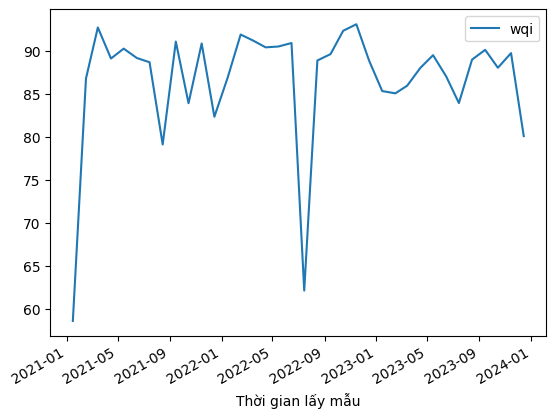

In [14]:
df[df['Tên trạm'] == 'Phước Hòa'].sort_values(by='Thời gian lấy mẫu').plot(x='Thời gian lấy mẫu', y='wqi', kind='line')

In [15]:
df.to_excel('data/kttv_mn_calcualted.xlsx', index=False)